# Experimento de 140 combinaciones, parte 5: optimización computacional

Cuánto cuesta cada modelo y cómo bajar ese costo sin perder desempeño. El cuaderno tiene tres partes.

La primera compara la complejidad teórica con la medida: se mide el tiempo de entrenamiento e inferencia al variar el número de filas n y
de variables p, y se ajusta t ≈ a·n^b en escala log-log para comparar el exponente b con el teórico. La segunda prueba las técnicas que pide
la guía para cada modelo: KNN con fuerza bruta, KD-Tree, Ball-Tree y FAISS; Ridge, Lasso y logística con SAGA; Naive Bayes con `partial_fit`;
XGBoost `hist` frente a `exact` con parada temprana; SVM con kernel frente a versiones lineales; `n_jobs` y backends de joblib; y el
perfilado de tiempo y memoria. La tercera junta todo en una tabla del modelo estándar frente al optimizado, con complejidad, tiempo de
entrenamiento, tiempo de inferencia, memoria y cambio en el desempeño.

Todo se mide en el primer pliegue externo (entrenamiento de unas 46 mil plantas, prueba de unas 12 mil), con la máquina libre: si hay otros
procesos pesados, los tiempos no sirven. Los tiempos de las secciones 2 a 6 son la mediana de 3 repeticiones; en las demás es una sola corrida.

In [1]:
import cProfile, io, os, pstats, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed, parallel_config
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, SGDClassifier, SGDRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from memory_profiler import memory_usage
from src import analisis, computacional as comp, config, cv

RAPIDO = os.environ.get("RAPIDO") == "1"   # solo para depurar el cuaderno; los resultados reportados son con RAPIDO = 0
REP = 1 if RAPIDO else 3
b = analisis.base()
tr, te = cv.externas(b.y_clf, b.grupos)[0]
prep = make_pipeline(SimpleImputer(strategy="median"), StandardScaler()).fit(b.X[tr])
Xtr, Xte = prep.transform(b.X[tr]), prep.transform(b.X[te])
ytr, yte = b.y_clf[tr], b.y_clf[te]
rtr, rte = b.y_reg[tr], b.y_reg[te]
if RAPIDO:
    Xtr, ytr, rtr, Xte, yte, rte = Xtr[:6000], ytr[:6000], rtr[:6000], Xte[:2000], yte[:2000], rte[:2000]
f1 = lambda y, p: f1_score(y, p, average="macro")
print(f"Entrenamiento {Xtr.shape}, prueba {Xte.shape}, núcleos {os.cpu_count()}, modo rápido: {RAPIDO}")

C:\Users\Enma\miniconda3\envs\solarpv-eda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Entrenamiento (46405, 15), prueba (11571, 15), núcleos 16, modo rápido: False


## 1. Complejidad teórica

| Modelo | Entrenamiento | Inferencia (por observación) | Fuente |
|---|---|---|---|
| KNN, fuerza bruta | O(1): solo guarda los datos | O(n·p) | Cover y Hart (1967) |
| KNN, KD-Tree | O(p·n·log n) | O(log n) en dimensión baja, tiende a O(n) cuando p crece | Friedman, Bentley y Finkel (1977) |
| Naive Bayes gaussiano | O(n·p) | O(p·K) | |
| Regresión logística (SAGA) | O(n·p) por época | O(p·K) | Defazio et al. (2014) |
| Ridge (Cholesky) | O(n·p² + p³) | O(p) | |
| Lasso (descenso por coordenadas) | O(n·p) por pasada | O(p) | Friedman, Hastie y Tibshirani (2010) |
| Árbol de decisión | O(p·n·log n) | O(profundidad) | Breiman et al. (1984) |
| Random Forest | O(T·m·n·log n), m variables por división | O(T·profundidad) | Breiman (2001) |
| XGBoost `exact` | O(T·p·n·log n) por el ordenamiento | O(T·profundidad) | Chen y Guestrin (2016) |
| XGBoost `hist` | O(T·p·n) para los histogramas, más O(T·p·bins) para las divisiones | O(T·profundidad) | Chen y Guestrin (2016) |
| SVM con kernel (SMO) | entre O(n²) y O(n³) | O(n_vs·p), n_vs = vectores de soporte | Platt (1998); Bottou y Lin (2007) |
| SVM lineal | O(n·p) por época | O(p) | Fan et al. (2008) |

K = clases, T = árboles. Para n la predicción teórica de los exponentes es: 1 en los lineales, Naive Bayes y XGBoost `hist`; algo más de 1
(n·log n) en árboles; entre 2 y 3 en el SVM con kernel; 0 en el entrenamiento de KNN y 1 en su inferencia por observación.

## 2. Exponente empírico al variar n

In [2]:
modelos_n = {
    "KNN (fuerza bruta)": KNeighborsClassifier(15, algorithm="brute"),
    "KNN (KD-Tree)": KNeighborsClassifier(15, algorithm="kd_tree"),
    "Naive Bayes": GaussianNB(),
    "Logística (saga)": LogisticRegression(solver="saga", tol=1e-3, max_iter=1000),
    "Árbol de decisión": DecisionTreeClassifier(random_state=config.SEED),
    "Random Forest (100)": RandomForestClassifier(100, n_jobs=1, random_state=config.SEED),
    "XGBoost hist (200)": XGBClassifier(n_estimators=200, tree_method="hist", n_jobs=1, random_state=config.SEED),
    "XGBoost exact (200)": XGBClassifier(n_estimators=200, tree_method="exact", n_jobs=1, random_state=config.SEED),
    "SVM RBF": SVC(),
    "SVM lineal": LinearSVC(),
}
tam = [1000, 2000, 4000] if RAPIDO else [2000, 4000, 8000, 16000, 32000, len(Xtr)]
filas, curvas = [], {}
for nombre, m in modelos_n.items():
    tt = [t for t in tam if not (nombre == "SVM RBF" and t > 16000)]  # el SVM con kernel se corta en 16 mil: más arriba tarda horas
    d = comp.escalamiento(m, Xtr, ytr, tt, X_pred=Xte[:2000], repeticiones=REP)
    curvas[nombre] = d
    b_fit, r2_fit = comp.exponente(d.n, d.t_entrenamiento)
    b_pred, r2_pred = comp.exponente(d.n, d.t_inferencia)
    filas.append({"modelo": nombre, "b entrenamiento": b_fit, "R² ajuste": r2_fit, "b inferencia": b_pred,
                  "t entrenamiento con n máx (s)": d.t_entrenamiento.iloc[-1], "t inferencia 2 mil (s)": d.t_inferencia.iloc[-1]})
exp_n = pd.DataFrame(filas).set_index("modelo")
exp_n.round(3)

,b entrenamiento,R² ajuste,b inferencia,t entrenamiento con n máx (s),t inferencia 2 mil (s)
modelo,,,,,
KNN (fuerza bruta),0.713,0.976,0.672,0.008,0.090
KNN (KD-Tree),0.978,0.985,0.767,0.105,1.021
Naive Bayes,0.783,0.971,-0.001,0.016,0.001
Logística (saga),0.639,0.931,0.041,0.485,0.000
Árbol de decisión,1.179,0.994,0.066,0.849,0.000
Random Forest (100),1.065,0.999,0.189,11.986,0.027
XGBoost hist (200),0.649,0.999,0.110,3.563,0.020
XGBoost exact (200),1.011,0.997,0.105,43.782,0.020
SVM RBF,1.846,1.000,0.790,2.941,0.594


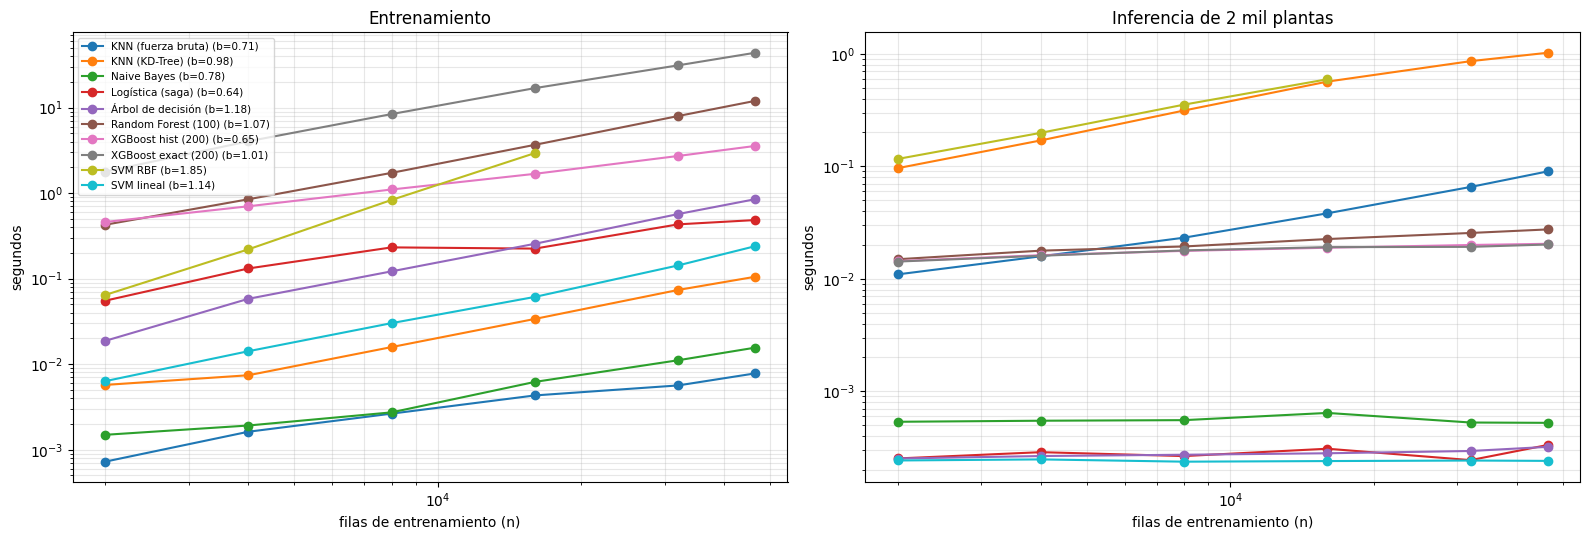

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for nombre, d in curvas.items():
    axes[0].loglog(d.n, d.t_entrenamiento, "o-", label=f"{nombre} (b={exp_n.loc[nombre, 'b entrenamiento']:.2f})")
    axes[1].loglog(d.n, d.t_inferencia, "o-", label=nombre)
axes[0].set_title("Entrenamiento"); axes[1].set_title("Inferencia de 2 mil plantas")
for ax in axes:
    ax.set_xlabel("filas de entrenamiento (n)"); ax.set_ylabel("segundos"); ax.grid(True, which="both", alpha=.3)
axes[0].legend(fontsize=7.5)
fig.tight_layout(); fig.savefig("fig_exp_complejidad.png", dpi=130, bbox_inches="tight"); plt.show()

## 3. Exponente empírico al variar p

Con n fijo, se entrena con las primeras 3, 6, 9, 12 y 15 variables. Para ver más allá de 15 se agregan copias con ruido de las variables
(hasta 60), que no aportan información pero sí costo.

In [4]:
rng = np.random.default_rng(config.SEED)
n_p = 4000 if RAPIDO else 16000
idx = rng.choice(len(Xtr), n_p, replace=False)
extra = np.hstack([Xtr[idx] + rng.normal(0, 0.1, (n_p, Xtr.shape[1])) for _ in range(3)])
X60 = np.hstack([Xtr[idx], extra])
ps = [3, 6, 9, 12, 15, 30, 60]
filas = []
for nombre in ["KNN (fuerza bruta)", "KNN (KD-Tree)", "Logística (saga)", "Árbol de decisión", "XGBoost hist (200)", "SVM lineal"]:
    tiempos = []
    for p in ps:
        m = clone(modelos_n[nombre])
        t_fit = comp.cronometrar(lambda: m.fit(X60[:, :p], ytr[idx]), REP)
        t_pred = comp.cronometrar(lambda: m.predict(np.hstack([Xte[:2000]] * 4)[:, :p]), REP)
        tiempos.append((p, t_fit, t_pred))
    t = np.array(tiempos)
    filas.append({"modelo": nombre, "b entrenamiento (p)": comp.exponente(t[:, 0], t[:, 1])[0],
                  "b inferencia (p)": comp.exponente(t[:, 0], t[:, 2])[0], "t entrenamiento p=60 / p=15": t[-1, 1] / t[4, 1]})
pd.DataFrame(filas).set_index("modelo").round(2)

,b entrenamiento (p),b inferencia (p),t entrenamiento p=60 / p=15
modelo,,,
KNN (fuerza bruta),0.30,0.15,1.09
KNN (KD-Tree),0.73,1.77,3.39
Logística (saga),1.78,0.11,15.84
Árbol de decisión,1.01,-0.05,6.03
XGBoost hist (200),0.65,0.05,3.18
SVM lineal,1.25,0.05,7.16


## 4. KNN: fuerza bruta, KD-Tree, Ball-Tree y FAISS

FAISS (Johnson et al., 2021) busca vecinos en C++ con instrucciones vectoriales. `IndexFlatL2` es exacto; `IndexHNSWFlat` es aproximado, con un
grafo navegable de varias capas (Malkov y Yashunin, 2020). k = 15, distancia euclidiana.

In [5]:
knn = {
    "scikit-learn, fuerza bruta": KNeighborsClassifier(15, algorithm="brute", n_jobs=1),
    "scikit-learn, KD-Tree": KNeighborsClassifier(15, algorithm="kd_tree", n_jobs=1),
    "scikit-learn, Ball-Tree": KNeighborsClassifier(15, algorithm="ball_tree", n_jobs=1),
    "FAISS exacto (Flat)": comp.KNNFaiss(15, exacto=True),
    "FAISS aproximado (HNSW)": comp.KNNFaiss(15, exacto=False),
}
filas = []
for nombre, m in knn.items():
    t_fit = comp.cronometrar(lambda: m.fit(Xtr, ytr), REP)
    t_pred = comp.cronometrar(lambda: m.predict(Xte), REP)
    filas.append({"método": nombre, "t entrenamiento (s)": t_fit, "t inferencia (s)": t_pred, "F1 macro": f1(yte, m.predict(Xte))})
t_knn = pd.DataFrame(filas).set_index("método")
t_knn["aceleración de la inferencia"] = t_knn.loc["scikit-learn, KD-Tree", "t inferencia (s)"] / t_knn["t inferencia (s)"]
t_knn.round(4)

,t entrenamiento (s),t inferencia (s),F1 macro,aceleración de la inferencia
método,,,,
"scikit-learn, fuerza bruta",0.0023,0.4838,0.7619,11.5666
"scikit-learn, KD-Tree",0.1072,5.5954,0.7619,1.0000
"scikit-learn, Ball-Tree",0.0644,8.8127,0.7619,0.6349
FAISS exacto (Flat),0.0019,0.7029,0.7619,7.9607
FAISS aproximado (HNSW),0.1922,0.0368,0.7593,151.8645


## 5. Modelos lineales: SAGA y descenso estocástico

SAGA (Defazio et al., 2014) es un gradiente estocástico con reducción de varianza: cada paso usa una sola fila, así que escala con n mejor que los
métodos que recorren toda la matriz. Para Lasso, scikit-learn no ofrece SAGA; la alternativa estocástica es `SGDRegressor` con penalización L1.

In [6]:
lin = [
    ("Logística", "lbfgs (estándar)", LogisticRegression(max_iter=1000), "clf"),
    ("Logística", "saga", LogisticRegression(solver="saga", tol=1e-3, max_iter=1000), "clf"),
    ("Ridge", "Cholesky (estándar)", Ridge(alpha=1.0, solver="cholesky"), "reg"),
    ("Ridge", "saga", Ridge(alpha=1.0, solver="saga", tol=1e-4, random_state=config.SEED), "reg"),
    ("Lasso", "descenso por coordenadas (estándar)", Lasso(alpha=1e-4, max_iter=10000), "reg"),
    ("Lasso", "SGD con L1", SGDRegressor(penalty="l1", alpha=1e-4, random_state=config.SEED), "reg"),
]
filas = []
for mod, solver, m, tarea in lin:
    y_a, y_b = (ytr, yte) if tarea == "clf" else (rtr, rte)
    t_fit = comp.cronometrar(lambda: m.fit(Xtr, y_a), REP)
    p = m.predict(Xte)
    filas.append({"modelo": mod, "solver": solver, "t entrenamiento (s)": t_fit,
                  "desempeño": f1(y_b, p) if tarea == "clf" else np.sqrt(mean_squared_error(y_b, p)),
                  "métrica": "F1 macro" if tarea == "clf" else "RMSE"})
pd.DataFrame(filas).set_index(["modelo", "solver"]).round(4)

t entrenamiento (s)  desempeño  \
modelo    solver                                                                
Logística lbfgs (estándar)                                  0.3421     0.6057   
          saga                                              0.4927     0.6052   
Ridge     Cholesky (estándar)                               0.0064     0.0939   
          saga                                              0.1172     0.0939   
Lasso     descenso por coordenadas (estándar)               0.0968     0.0939   
          SGD con L1                                        0.0413     0.0940   

                                                métrica  
modelo    solver                                         
Logística lbfgs (estándar)                     F1 macro  
          saga                                 F1 macro  
Ridge     Cholesky (estándar)                      RMSE  
          saga                                     RMSE  
Lasso     descenso por coordenadas (estándar)      RMSE  
          SGD con L1                               RMSE

## 6. Naive Bayes con `partial_fit`

`partial_fit` actualiza medias y varianzas por bloques, sin tener todos los datos en memoria. Sirve cuando la base no cabe en RAM o llega por partes.
Se compara el tiempo, el pico de memoria y si el modelo resultante es el mismo.

In [7]:
def nb_completo():
    return GaussianNB().fit(Xtr, ytr)
def nb_bloques(tam=5000):
    m = GaussianNB()
    for i in range(0, len(Xtr), tam):
        m.partial_fit(Xtr[i:i + tam], ytr[i:i + tam], classes=[0, 1, 2])
    return m
a, c = nb_completo(), nb_bloques()
pd.DataFrame({
    "t entrenamiento (s)": [comp.cronometrar(nb_completo, REP), comp.cronometrar(nb_bloques, REP)],
    "memoria pico (MB, tracemalloc)": [comp.memoria_pico(nb_completo), comp.memoria_pico(nb_bloques)],
    "F1 macro": [f1(yte, a.predict(Xte)), f1(yte, c.predict(Xte))],
}, index=["fit completo", "partial_fit en bloques de 5 mil"]).round(4).assign(
    **{"diferencia máxima en las medias": [0.0, float(np.abs(a.theta_ - c.theta_).max())]})

,t entrenamiento (s),"memoria pico (MB, tracemalloc)",F1 macro,diferencia máxima en las medias
fit completo,0.0123,8.0589,0.4349,0.000000e+00
partial_fit en bloques de 5 mil,0.0160,1.2119,0.4350,2.074729e-14


## 7. XGBoost: `hist` frente a `exact`, parada temprana y GPU

La parada temprana (early stopping) usa una validación separada del entrenamiento (20 %, por bloques), nunca la prueba: si la prueba decide cuándo parar,
deja de ser prueba.

In [8]:
from sklearn.model_selection import GroupShuffleSplit
g_tr = b.grupos[tr][:len(Xtr)]
a_i, v_i = next(GroupShuffleSplit(1, test_size=0.2, random_state=config.SEED).split(Xtr, ytr, g_tr))
filas = []
for metodo in ["exact", "hist"]:
    for parada in [False, True]:
        kw = dict(n_estimators=1000, learning_rate=0.1, max_depth=6, tree_method=metodo, n_jobs=1, random_state=config.SEED)
        if parada:
            kw["early_stopping_rounds"] = 30
        m = XGBClassifier(**kw)
        fit = (lambda: m.fit(Xtr[a_i], ytr[a_i], eval_set=[(Xtr[v_i], ytr[v_i])], verbose=False)) if parada else (lambda: m.fit(Xtr[a_i], ytr[a_i]))
        t = comp.cronometrar(fit, 1)
        filas.append({"tree_method": metodo, "early stopping": parada, "árboles usados": (m.best_iteration + 1) if parada else 1000,
                      "t entrenamiento (s)": t, "F1 macro": f1(yte, m.predict(Xte))})
xgb_t = pd.DataFrame(filas).set_index(["tree_method", "early stopping"])
display(xgb_t.round(4))
try:
    XGBClassifier(n_estimators=5, device="cuda").fit(Xtr[:500], ytr[:500])
    print("Hay GPU con CUDA disponible para XGBoost.")
except Exception as e:
    print("Sin GPU CUDA en esta máquina; la comparación con GPU no se puede hacer aquí.", type(e).__name__)

árboles usados  t entrenamiento (s)  F1 macro
tree_method parada temprana                                               
exact       False                      1000             168.4861    0.8899
            True                        147              31.4423    0.8865
hist        False                      1000              13.7082    0.8858
            True                         78               1.7661    0.8860

Hay GPU con CUDA disponible para XGBoost.


C:\Users\Enma\miniconda3\envs\solarpv-eda\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:08:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Enma\miniconda3\envs\solarpv-eda\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:08:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


## 8. SVM: kernel completo frente a versiones lineales

El SVM con kernel RBF no escala a 46 mil filas (por eso el experimento lo entrena con 5 mil). Alternativas: SVM lineal (`LinearSVC`, Fan et al., 2008),
SGD con pérdida bisagra, y la aproximación de Nyström del kernel RBF seguida de un SVM lineal (Williams y Seeger, 2001), que conserva parte de la no linealidad.

In [9]:
svm = [
    ("SVC RBF, 5 mil filas", SVC(), 5000),
    ("SVC RBF, 10 mil filas", SVC(), 10000),
    ("LinearSVC, todas", LinearSVC(), None),
    ("SGD bisagra, todas", SGDClassifier(loss="hinge", random_state=config.SEED), None),
    ("Nyström 500 + LinearSVC, todas", make_pipeline(Nystroem(n_components=500, random_state=config.SEED), LinearSVC()), None),
]
filas = []
for nombre, m, n in svm:
    n = min(n or len(Xtr), len(Xtr))
    t_fit = comp.cronometrar(lambda: m.fit(Xtr[:n], ytr[:n]), 1)
    t_pred = comp.cronometrar(lambda: m.predict(Xte), 1)
    filas.append({"método": nombre, "filas": n, "t entrenamiento (s)": t_fit, "t inferencia (s)": t_pred, "F1 macro": f1(yte, m.predict(Xte))})
pd.DataFrame(filas).set_index("método").round(4)

,filas,t entrenamiento (s),t inferencia (s),F1 macro
método,,,,
"SVC RBF, 5 mil filas",5000,0.1429,0.4768,0.4103
"SVC RBF, 10 mil filas",10000,0.6934,1.5494,0.7701
"LinearSVC, todas",46405,0.1648,0.0008,0.5504
"SGD bisagra, todas",46405,0.3416,0.0011,0.5721
"Nyström 500 + LinearSVC, todas",46405,15.5527,0.1000,0.8228


## 9. Paralelismo: `n_jobs` y backends de joblib

Random Forest entrena cada árbol por separado, así que se paraleliza casi perfecto. Se mide la aceleración con 1 a 16 procesos y se compara la ley de
Amdahl (Amdahl, 1967). Después, el mismo trabajo de validación cruzada con dos backends de joblib: `loky` (procesos) y `threading` (hilos, limitados
por el GIL de Python salvo en código que lo libera).

In [10]:
nucleos = [1, 2, 4] if RAPIDO else [1, 2, 4, 8, 16]
t_rf = {}
for nj in nucleos:
    m = RandomForestClassifier(200, n_jobs=nj, random_state=config.SEED)
    t_rf[nj] = comp.cronometrar(lambda: m.fit(Xtr, ytr), 1 if not RAPIDO else 1)
s = pd.Series(t_rf, name="segundos").to_frame()
s["aceleración"] = s.segundos.iloc[0] / s.segundos
fraccion_serial = None
if len(s) > 2:
    from scipy.optimize import curve_fit
    amdahl = lambda n, f: 1 / (f + (1 - f) / n)
    fraccion_serial = curve_fit(amdahl, s.index.values.astype(float), s["aceleración"].values, p0=[0.05], bounds=(0, 1))[0][0]
    s["Amdahl ajustado"] = amdahl(s.index.values.astype(float), fraccion_serial)
display(s.round(3))
print("Fracción serial estimada:", None if fraccion_serial is None else round(fraccion_serial, 3))

from sklearn.model_selection import cross_val_score
filas = []
for backend in ["loky", "threading"]:
    with parallel_config(backend=backend):
        t = comp.cronometrar(lambda: cross_val_score(DecisionTreeClassifier(random_state=0), Xtr, ytr, cv=8, n_jobs=8), 1)
    filas.append({"backend": backend, "8 árboles en paralelo (s)": t})
pd.DataFrame(filas).set_index("backend").round(3)

,segundos,aceleración,Amdahl ajustado
1,23.851,1.000,1.000
2,12.550,1.900,1.958
4,6.580,3.625,3.756
8,3.439,6.936,6.948
16,1.972,12.094,12.079


Fracción serial estimada: 0.022


,8 árboles en paralelo (s)
backend,
loky,3.149
threading,0.873


## 10. Perfilado de una evaluación del experimento

Una evaluación típica: SMOTE + XGBoost en un pliegue interno. `cProfile` dice en qué funciones se va el tiempo; `memory_profiler`, el pico de memoria del proceso.

In [11]:
from src import balancing, models
pipe = balancing.construir(models.estimador("clf", "XGBoost"), "XGBoost", "smote").set_params(m__n_estimators=200, m__max_depth=6)
perfil = cProfile.Profile()
perfil.enable(); pipe.fit(b.X[tr][:len(Xtr)], ytr); perfil.disable()
salida = io.StringIO()
pstats.Stats(perfil, stream=salida).sort_stats("cumulative").print_stats(12)
print("\n".join(l for l in salida.getvalue().splitlines() if l.strip())[:3500])
pico = max(memory_usage((pipe.fit, (b.X[tr][:len(Xtr)], ytr)), interval=0.1))
print(f"Pico de memoria del proceso durante el fit: {pico:.0f} MB")

         30829 function calls (30802 primitive calls) in 8.354 seconds
   Ordered by: cumulative time
   List reduced from 666 to 12 due to restriction <12>
   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    8.356    4.178 C:\Users\Enma\miniconda3\envs\solarpv-eda\Lib\site-packages\IPython\core\interactiveshell.py:3739(run_code)
        2    0.000    0.000    8.356    4.178 {built-in method builtins.exec}
      6/1    0.001    0.000    8.354    8.354 C:\Users\Enma\miniconda3\envs\solarpv-eda\Lib\site-packages\sklearn\base.py:1381(wrapper)
        1    0.000    0.000    8.352    8.352 C:\Users\Enma\miniconda3\envs\solarpv-eda\Lib\site-packages\imblearn\pipeline.py:451(fit)
     11/1    0.000    0.000    7.055    7.055 C:\Users\Enma\miniconda3\envs\solarpv-eda\Lib\site-packages\xgboost\core.py:732(inner_f)
        1    0.000    0.000    7.055    7.055 C:\Users\Enma\miniconda3\envs\solarpv-eda\Lib\site-packages\xgboost\sklearn.py:1719(fi

Pico de memoria del proceso durante el fit: 621 MB


## 11. Estándar frente a optimizado

Una fila por modelo, con lo medido arriba. "Estándar" es la implementación por defecto; "optimizado", la técnica de este cuaderno que más
acelera sin perder desempeño apreciable.

In [12]:
def mide(m, X, y, Xp, yp, tarea="clf"):
    t_fit = comp.cronometrar(lambda: m.fit(X, y), 1)
    t_pred = comp.cronometrar(lambda: m.predict(Xp), 1)
    mem = comp.memoria_pico(lambda: clone(m).fit(X, y))
    p = m.predict(Xp)
    return t_fit, t_pred, mem, (f1(yp, p) if tarea == "clf" else -np.sqrt(mean_squared_error(yp, p)))

pares = [
    ("KNN", "KD-Tree", "O(n·p) por consulta en p alto", KNeighborsClassifier(15, algorithm="kd_tree"),
     "FAISS exacto", "O(n·p) por consulta, vectorizado", comp.KNNFaiss(15), "clf"),
    ("Naive Bayes", "fit completo", "O(n·p)", GaussianNB(), "partial_fit en bloques", "O(n·p), memoria O(bloque·p)", None, "clf"),
    ("Logística", "lbfgs", "O(n·p) por iteración", LogisticRegression(max_iter=1000), "saga", "O(n·p) por época",
     LogisticRegression(solver="saga", tol=1e-3, max_iter=1000), "clf"),
    ("Ridge", "Cholesky", "O(n·p² + p³)", Ridge(solver="cholesky"), "saga", "O(n·p) por época", Ridge(solver="saga", random_state=0), "reg"),
    ("XGBoost", "exact, 300 árboles", "O(T·p·n·log n)", XGBClassifier(n_estimators=300, tree_method="exact", n_jobs=1),
     "hist, 300 árboles", "O(T·p·n)", XGBClassifier(n_estimators=300, tree_method="hist", n_jobs=1), "clf"),
    ("Random Forest", "200 árboles, 1 núcleo", "O(T·m·n·log n)", RandomForestClassifier(200, n_jobs=1, random_state=0),
     "200 árboles, 16 núcleos", "O(T·m·n·log n / núcleos)", RandomForestClassifier(200, n_jobs=-1, random_state=0), "clf"),
    ("SVM", "SVC RBF, 10 mil filas", "O(n²) a O(n³)", SVC(), "Nyström 500 + LinearSVC, todas", "O(n·c·p + n·c)",
     make_pipeline(Nystroem(n_components=500, random_state=0), LinearSVC()), "clf"),
]
filas = []
for mod, n_est, c_est, est, n_opt, c_opt, opt, tarea in pares:
    y_a, y_b = (ytr, yte) if tarea == "clf" else (rtr, rte)
    n_e = min(10000, len(Xtr)) if mod == "SVM" else len(Xtr)
    e = mide(est, Xtr[:n_e], y_a[:n_e], Xte, y_b, tarea)
    if opt is None:  # Naive Bayes por bloques
        t0 = comp.cronometrar(nb_bloques, 1); m = nb_bloques()
        o = (t0, comp.cronometrar(lambda: m.predict(Xte), 1), comp.memoria_pico(nb_bloques), f1(yte, m.predict(Xte)))
    else:
        o = mide(opt, Xtr, y_a, Xte, y_b, tarea)
    filas.append({"modelo": mod, "estándar": n_est, "complejidad estándar": c_est, "optimizado": n_opt, "complejidad optimizada": c_opt,
                  "t entrenamiento (s) est → opt": f"{e[0]:.2f} → {o[0]:.2f}", "t inferencia (s) est → opt": f"{e[1]:.3f} → {o[1]:.3f}",
                  "memoria pico (MB) est → opt": f"{e[2]:.0f} → {o[2]:.0f}",
                  "Δ desempeño": o[3] - e[3], "métrica": "F1 macro" if tarea == "clf" else "−RMSE"})
pd.DataFrame(filas).set_index("modelo")

,estándar,complejidad estándar,optimizado,complejidad optimizada,t entrenamiento (s) est → opt,t inferencia (s) est → opt,memoria pico (MB) est → opt,Δ desempeño,métrica
modelo,,,,,,,,,
KNN,KD-Tree,O(n·p) por consulta en p alto,FAISS exacto,"O(n·p) por consulta, vectorizado",0.10 → 0.00,5.232 → 0.655,2 → 3,0.000000e+00,F1 macro
Naive Bayes,fit completo,O(n·p),partial_fit en bloques,"O(n·p), memoria O(bloque·p)",0.02 → 0.03,0.006 → 0.005,8 → 1,2.621397e-05,F1 macro
Logística,lbfgs,O(n·p) por iteración,saga,O(n·p) por época,0.29 → 0.48,0.001 → 0.001,3 → 2,-5.352368e-04,F1 macro
Ridge,Cholesky,O(n·p² + p³),saga,O(n·p) por época,0.01 → 0.12,0.000 → 0.000,6 → 7,2.130114e-07,−RMSE
XGBoost,"exact, 300 árboles",O(T·p·n·log n),"hist, 300 árboles",O(T·p·n),64.20 → 5.40,0.160 → 0.165,0 → 0,-4.124816e-04,F1 macro
Random Forest,"200 árboles, 1 núcleo",O(T·m·n·log n),"200 árboles, 16 núcleos",O(T·m·n·log n / núcleos),23.46 → 1.98,0.203 → 0.084,6 → 47,0.000000e+00,F1 macro
SVM,"SVC RBF, 10 mil filas",O(n²) a O(n³),"Nyström 500 + LinearSVC, todas",O(n·c·p + n·c),0.69 → 16.38,1.552 → 0.106,1 → 356,5.652856e-02,F1 macro


## 12. Interpretación

Los exponentes medidos al variar n siguen lo esperado en casi todos los modelos: cerca de 1 en Naive Bayes, la regresión logística con SAGA, XGBoost `hist` y el SVM lineal, y algo más de 1 en los árboles (1.18 en el árbol de decisión y 1.07 en Random Forest). El SVM con kernel es el que más crece, con un exponente de 1.85 hasta 16 mil filas, por debajo del rango de 2 a 3 que dice la teoría. KNN mide 0.71 en entrenamiento, donde la teoría dice 0 porque solo guarda los datos. Al variar p, KNN con fuerza bruta casi no cambia (exponente de 0.30), mientras que el KD-Tree pierde su ventaja: entrena 3.4 veces más lento con 60 variables que con 15 y su exponente de inferencia es 1.77.

Con 15 variables, la fuerza bruta de KNN (0.48 s para predecir las 11.5 mil plantas de prueba) le gana al KD-Tree (5.6 s) y al Ball-Tree (8.8 s). FAISS exacto tarda 0.70 s y FAISS aproximado (HNSW) 0.037 s, unas 150 veces menos que el KD-Tree, con 0.003 menos de F1. En los modelos lineales SAGA no aceleró nada con p = 15: la logística pasó de 0.34 s a 0.49 s y Ridge de 0.006 s a 0.12 s. Solo Lasso con SGD fue más rápido (0.041 s frente a 0.097 s), con el mismo RMSE. `partial_fit` en Naive Bayes baja el pico de memoria de 8.1 a 1.2 MB con el mismo F1. En XGBoost, `hist` es unas 12 veces más rápido que `exact` con 1000 árboles (13.7 s contra 168.5 s) y la parada temprana lo deja en 1.8 s con 78 árboles, sin perder F1. En el SVM, el SVC con 10 mil filas tarda 0.69 s y Nyström con LinearSVC tarda 15.6 s con todas las filas, pero predice unas 15 veces más rápido y sube el F1 de 0.770 a 0.823. La comparación con GPU no se pudo hacer: XGBoost avisó que no encontró una GPU y usó la CPU, aunque el mensaje de esa celda diga lo contrario.

Con Random Forest, 16 núcleos aceleran 12.1 veces (de 23.9 s a 2.0 s) y la ley de Amdahl ajusta una fracción serial de 0.022. Con 8 árboles de decisión en paralelo, el backend `threading` (0.87 s) fue más rápido que `loky` (3.15 s). En el perfilado de una evaluación con SMOTE y XGBoost de 200 árboles, el 80 % de los 8.4 s se va en entrenar XGBoost y 1.2 s en SMOTE, y el pico de memoria es de 621 MB, así que el límite es el procesador y no la memoria.

En la tabla de estándar frente a optimizado, las mejoras reales son XGBoost de `exact` a `hist` (de 64.2 s a 5.4 s con 300 árboles, con el F1 casi igual), Random Forest con 16 núcleos (de 23.5 s a 2.0 s) y KNN con FAISS (inferencia de 5.2 s a 0.66 s). En Naive Bayes la ventaja es de memoria y en el SVM con Nyström de inferencia (de 1.6 s a 0.11 s), a costa de más tiempo de entrenamiento y de memoria. En la logística y en Ridge, SAGA no gana nada con 15 variables.

## Referencias

- Amdahl, G. M. (1967). Validity of the single processor approach to achieving large scale computing capabilities. En *AFIPS Spring Joint Computer Conference* (pp. 483-485). https://doi.org/10.1145/1465482.1465560
- Bottou, L. y Lin, C.-J. (2007). Support vector machine solvers. En *Large-Scale Kernel Machines* (pp. 1-27). MIT Press.
- Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5-32. https://doi.org/10.1023/A:1010933404324
- Breiman, L., Friedman, J. H., Olshen, R. A. y Stone, C. J. (1984). *Classification and regression trees*. Wadsworth.
- Chen, T. y Guestrin, C. (2016). XGBoost: A scalable tree boosting system. En *Proceedings of the 22nd ACM SIGKDD* (pp. 785-794). https://doi.org/10.1145/2939672.2939785
- Cover, T. y Hart, P. (1967). Nearest neighbor pattern classification. *IEEE Transactions on Information Theory, 13*(1), 21-27. https://doi.org/10.1109/TIT.1967.1053964
- Defazio, A., Bach, F. y Lacoste-Julien, S. (2014). SAGA: A fast incremental gradient method with support for non-strongly convex composite objectives. *Advances in Neural Information Processing Systems, 27*.
- Fan, R.-E., Chang, K.-W., Hsieh, C.-J., Wang, X.-R. y Lin, C.-J. (2008). LIBLINEAR: A library for large linear classification. *Journal of Machine Learning Research, 9*, 1871-1874.
- Friedman, J. H., Bentley, J. L. y Finkel, R. A. (1977). An algorithm for finding best matches in logarithmic expected time. *ACM Transactions on Mathematical Software, 3*(3), 209-226. https://doi.org/10.1145/355744.355745
- Friedman, J., Hastie, T. y Tibshirani, R. (2010). Regularization paths for generalized linear models via coordinate descent. *Journal of Statistical Software, 33*(1), 1-22. https://doi.org/10.18637/jss.v033.i01
- Johnson, J., Douze, M. y Jégou, H. (2021). Billion-scale similarity search with GPUs. *IEEE Transactions on Big Data, 7*(3), 535-547. https://doi.org/10.1109/TBDATA.2019.2921572
- Malkov, Y. A. y Yashunin, D. A. (2020). Efficient and robust approximate nearest neighbor search using hierarchical navigable small world graphs. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 42*(4), 824-836. https://doi.org/10.1109/TPAMI.2018.2889473
- Platt, J. (1998). *Sequential minimal optimization: A fast algorithm for training support vector machines* (MSR-TR-98-14). Microsoft Research.
- Williams, C. K. I. y Seeger, M. (2001). Using the Nyström method to speed up kernel machines. *Advances in Neural Information Processing Systems, 13*.